Saving Churn Prediction.xlsx to Churn Prediction (1).xlsx
Training Data Preview:
  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credi

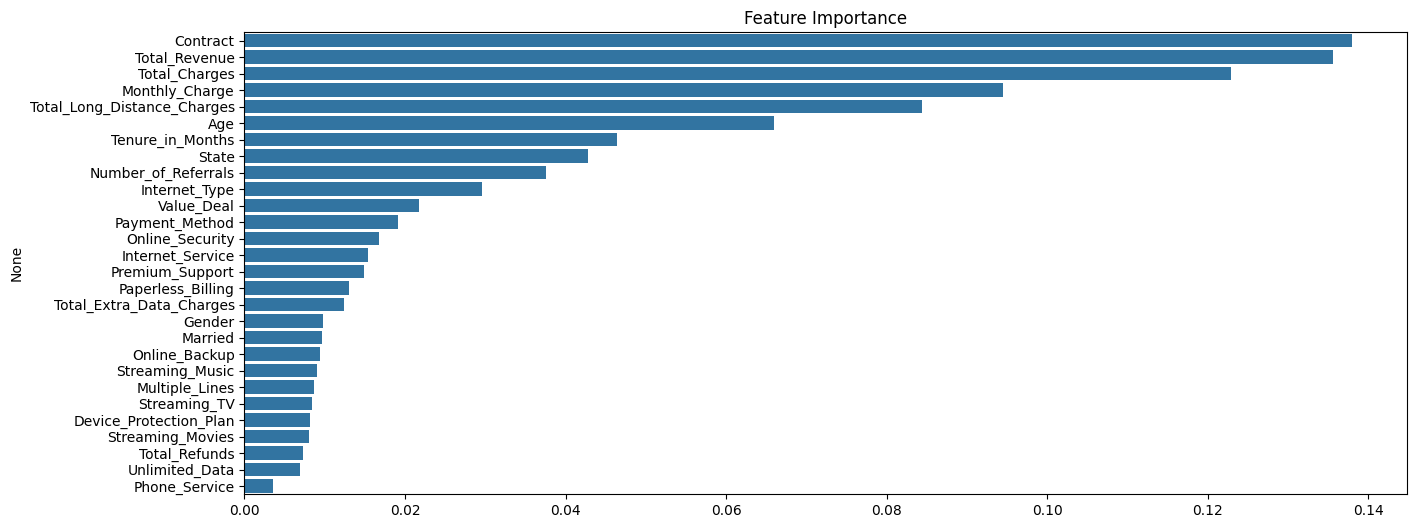


New Data Preview:
  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      72.099998     72.099998         

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================
# INSTALL REQUIRED LIBRARIES (if needed)
# =========================================
!pip install openpyxl

# =========================================
# IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import joblib
from google.colab import files

# =========================================
# UPLOAD FILE
# =========================================
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# =========================================
# LOAD TRAINING DATA
# =========================================
data = pd.read_excel(file_path, sheet_name='vw_ChurnData')

print("Training Data Preview:")
print(data.head())

# =========================================
# DATA PREPROCESSING
# =========================================

# Drop unnecessary columns
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# Columns to encode
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical columns
label_encoders = {}

for col in columns_to_encode:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le

# Encode target
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Drop any rows with missing target
data = data.dropna(subset=['Customer_Status'])

# Split features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# TRAIN MODEL
# =========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# =========================================
# MODEL EVALUATION
# =========================================
y_pred = rf_model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================
# FEATURE IMPORTANCE
# =========================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(15,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Feature Importance")
plt.show()

# =========================================
# SAVE MODEL & ENCODERS
# =========================================
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(label_encoders, "encoders.pkl")

# =========================================
# LOAD NEW DATA (PREDICTION)
# =========================================
new_data = pd.read_excel(file_path, sheet_name='vw_JoinData')

print("\nNew Data Preview:")
print(new_data.head())

# Backup original
original_data = new_data.copy()

# Drop unused columns
new_data = new_data.drop(
    ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
    axis=1,
    errors='ignore'
)

# =========================================
# APPLY SAME ENCODING
# =========================================
for col in new_data.columns:
    if col in label_encoders:
        le = label_encoders[col]

        # Handle unseen labels safely
        new_data[col] = new_data[col].astype(str)
        new_data[col] = new_data[col].apply(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        new_data[col] = le.transform(new_data[col])

# =========================================
# MAKE PREDICTIONS
# =========================================
predictions = rf_model.predict(new_data)

# Add predictions
original_data['Customer_Status_Predicted'] = predictions

# Filter churned customers
churned_customers = original_data[
    original_data['Customer_Status_Predicted'] == 1
]

# =========================================
# SAVE OUTPUT
# =========================================
output_file = "Predictions.csv"
churned_customers.to_csv(output_file, index=False)

print(f"\nSaved churn predictions to {output_file}")

# Download file
files.download(output_file)